In [56]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
import scipy as sp

import scipy.optimize as opt
from scipy.optimize import curve_fit

# load the RGB values from file
from matplotlib.colors import ListedColormap

# nside = 2048 #resolution of the map in pixels

In [57]:
hdul = fits.open("/home/gscianna/codes/CMBxunWISE/maps/SMICA-noSZ.fits")
# hdul_1 = fits.open("/home/gscianna/codes/CMBxunWISE/maps/WPR1_CMB_muK.fits")

T_nested = hdul[1].data["I_STOKES"].reshape(-1)     # or: .flatten() to reshape the data to a 1D array
T_ring = hp.reorder(T_nested, n2r=True)     # convert from NESTED to RING ordering

print(T_ring.shape)         # should be (50331648,)
print(hp.get_nside(T_ring)) # should be 2048

(50331648,)
2048


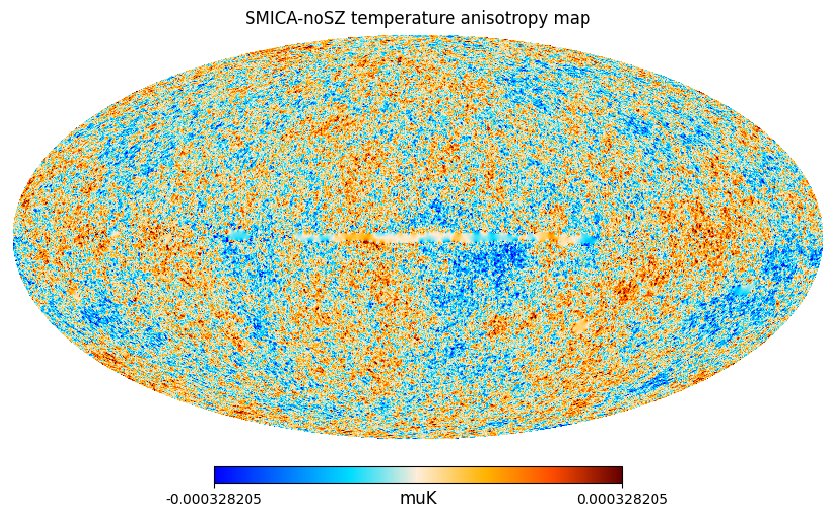

In [58]:
cmb_data = np.array(T_ring, dtype=np.float64)

# custom colormap
colors = np.loadtxt("color_map.txt") / 255.0
cmap = ListedColormap(colors)
cmap.set_bad("white")
cmap.set_under("white")


# remove monopole/dipole
cmb_clean, monopole, dipole = hp.remove_dipole(cmb_data, fitval=True)

cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

# choose visualization range
sigma = np.nanstd(cmb_clean)

hp.mollview(
    cmb_clean,
    cmap=cmap,
    min=-3*sigma,
    max=3*sigma,
    title="SMICA-noSZ temperature anisotropy map",
    bgcolor="white",
    badcolor="white",
    unit="muK"
)

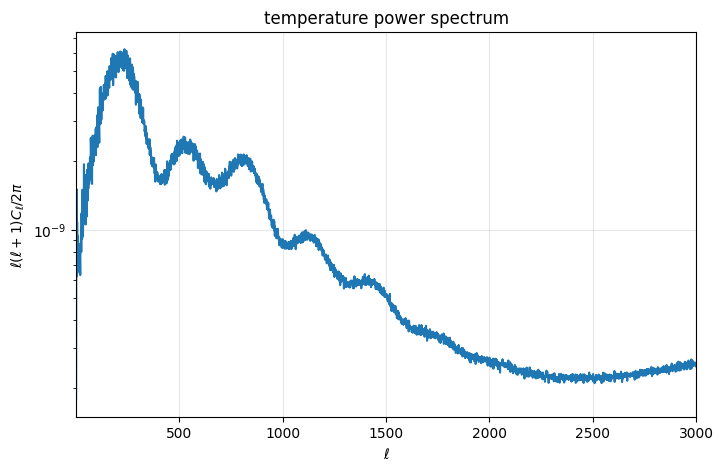

In [59]:
nside = hp.get_nside(cmb_clean)
l_max = 3000

alm = hp.map2alm(cmb_clean, lmax=l_max, pol=False)

cl = hp.alm2cl(alm)      # angular power spectrum C_l
ell = np.arange(len(cl))

plt.figure(figsize=(8,5))
plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi))
plt.xlabel(r"$\ell$")
plt.xlim(2, 3000)
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
plt.yscale('log')

# plotting the points on the graph
# plt.plot(x,y)
plt.title("temperature power spectrum")
plt.grid(alpha=0.3)
plt.show()

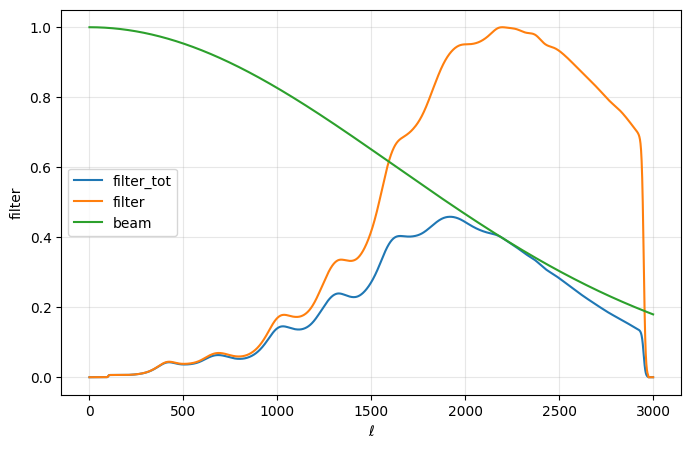

In [60]:
filter = np.loadtxt("filter.txt") #2D array that contains ell in first column and mask values in second column

FWMN = 5.0  # full width at half maximum of the beam in arcminutes
FWHM = FWMN * np.pi / (180 * 60)  # convert FWHM from arcminutes to radians

ell = np.arange(3001)
beam = np.exp(-0.5 * ell * (ell + 1) * (FWHM / np.sqrt((8 * np.log(2))))**2)

filter_tot = filter[:, 1] * beam

plt.figure(figsize=(8,5))
plt.plot(ell, filter_tot, label="filter_tot")
plt.plot(ell, filter[:, 1], label="filter")
plt.plot(ell, beam, label="beam")
plt.xlabel(r"$\ell$")
plt.ylabel("filter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

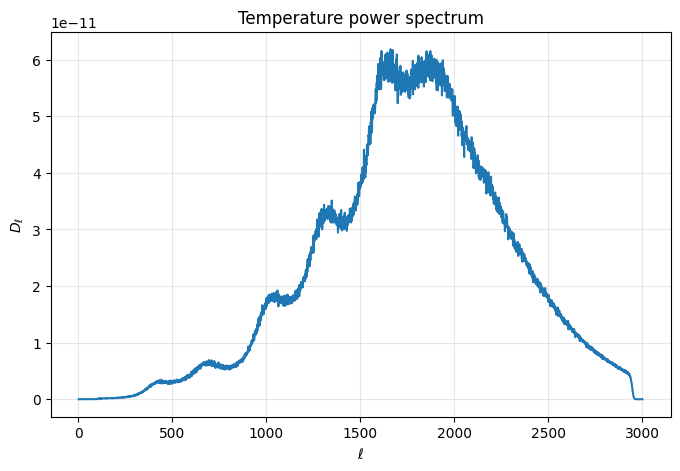

In [61]:
alm_filtered = hp.almxfl(alm, filter_tot)
# print(alm_filtered.shape)

cl = hp.alm2cl(alm_filtered)    # angular power spectrum C_l of the filtered alm coefficients
ell = np.arange(len(cl))

plt.figure(figsize=(8,5))
plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi), label='Filtered')
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.title("Temperature power spectrum")
plt.grid(alpha=0.3)
plt.show()

In [62]:
# go from filtered alm back to real space map (pixel space)
temp_filtered = hp.alm2map(alm_filtered, nside=nside)

# hp.mollview(
#     temp_filtered,
#     cmap=cmap,
#     title="Filtered CMB map in real space",
#     bgcolor="white",
#     badcolor="white",
#     unit="muK"
# )

In [63]:
# square the temperature map in pixel space
temp_filtered_squared = temp_filtered**2

# hp.mollview(
#     temp_filtered_squared,
#     cmap=cmap,
#     title="Squared filtered CMB map in real space",
#     bgcolor="white",
#     badcolor="white",
#     unit="(muK)^2",
#     min=0,
#     max=np.nanpercentile(temp_filtered_squared, 99)
# )

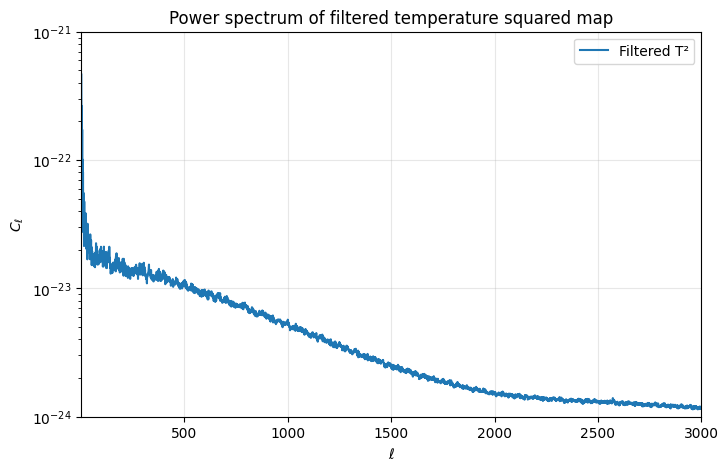

In [64]:
# compute alm of the squared map
alm_squared = hp.map2alm(temp_filtered_squared)

# compute Cl of the squared temperature field
cl_squared = hp.alm2cl(alm_squared)

ell = np.arange(len(cl_squared))

plt.figure(figsize=(8, 5))
plt.plot(
    ell[2:],
    cl_squared[2:],
    label="Filtered T²"
)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale('log')
plt.xlim(2, 3000)
plt.ylim(1e-24, 1e-21)
plt.title("Power spectrum of filtered temperature squared map")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [65]:
# mask = hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask.fits")
mask = hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask_unWISE_full_v10_C.fits")
# hp.mollview(unWISE_mask, coord=['C', 'G'])

# samples = {
#     "blue": hp.read_map("../galaxy_samples/1_delta.fits", field=0),
#     "green": hp.read_map("../galaxy_samples/2_delta.fits", field=0),
#     "red": hp.read_map("../galaxy_samples/7_delta.fits", field=0),
# }

delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/1_delta.fits", field=0)
nside_gal = hp.get_nside(delta_blue)

# ell_max = 3000
# delta_ell = 100

# b = nmt.NmtBin.from_edges(
#     np.arange(0, ell_max, delta_ell),
#     np.arange(delta_ell, ell_max + delta_ell, delta_ell)
# )

# ell_arr = b.get_effective_ells()

b = nmt.NmtBin.from_nside_linear(nside_gal, 200)

cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

### Txdelta_g direct cross correlation

In [66]:
def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)

    return cl_decoupled

In [67]:
arr_blue = np.array([
    [955.0561797752808, 0.020716292134831504],
    [853.9325842696629, 0.022801966292134906],
    [752.808988764045, 0.026137640449438226],
    [651.6853932584269, 0.02947331460674163],
    [550.5617977528087, 0.034683988764044965],
    [449.4382022471908, 0.04239466292134833],
    [351.68539325842676, 0.057598314606741585],
    [250.56179775280896, 0.08718398876404494],
])

arr_green = np.array([])
arr_red = np.array([])

### data from krolewski for comparison

In [68]:
delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/1_delta.fits", field=0)
delta_green = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/2_delta.fits", field=0)
delta_red = hp.read_map("/home/gscianna/codes/CMBxunWISE/ola_data/7_delta.fits", field=0)
nside_gal = hp.get_nside(delta_blue)

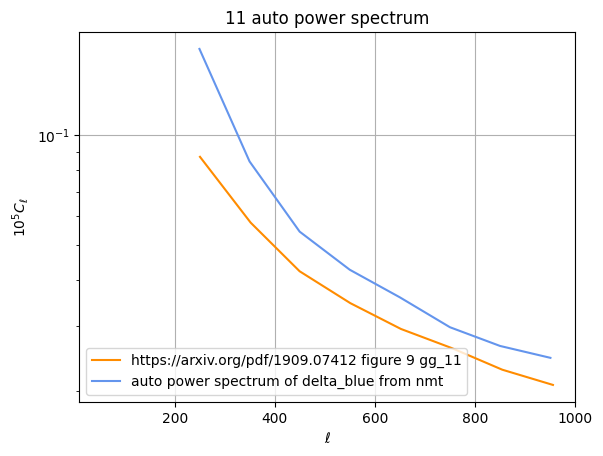

In [69]:
l_min = 200
l_max = 1000
delta_l = 100

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

shot_noise = 1. / hp.nside2npix(nside) / np.mean(delta_blue + 1)

gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

wsp_gal = nmt.NmtWorkspace()
wsp_gal.compute_coupling_matrix(gal_field, gal_field, b)
auto_gal = compute_master(gal_field, gal_field, wsp_gal)

cl_coupled = nmt.compute_coupled_cell(gal_field, gal_field)
cl_decoupled = wsp_gal.decouple_cell(cl_coupled)
ell = b.get_effective_ells()

plt.plot(
    arr_blue[:, 0],
    arr_blue[:, 1],
    color="darkorange",
    label="https://arxiv.org/pdf/1909.07412 figure 9 gg_11"
)

plt.plot(
    ell,
    1e5 * cl_decoupled[0],
    color="cornflowerblue",
    label="auto power spectrum of delta_blue from nmt"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.yscale("log")
plt.xlim(10, 1000)
plt.title("11 auto power spectrum")
plt.grid()
plt.legend()
plt.show()

In [81]:
l_min = 300
l_max = 2900
delta_l = 200

temp_field = nmt.NmtField(mask, [temp_filtered], lmax=l_max)
delta_blue_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)
# gal_field = nmt.NmtField(mask, [samples["blue"]])

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

cl_dir_cross = nmt.compute_full_master(temp_field, delta_blue_field, b)

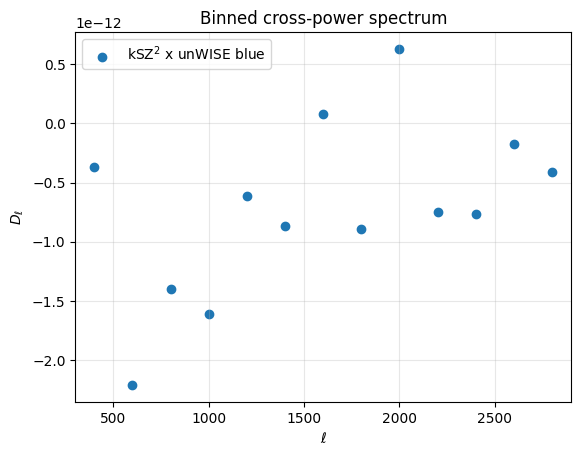

In [82]:
wsp = nmt.NmtWorkspace()
temp_squared_field = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

wsp.compute_coupling_matrix(temp_squared_field, gal_field, b)

cl_t2xg = compute_master(temp_squared_field, gal_field, wsp)
ell = b.get_effective_ells()

Dl = ell * (ell + 1) * cl_t2xg[0] / (2 * np.pi)

plt.scatter(ell, Dl, label="kSZ$^2$ x unWISE blue")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

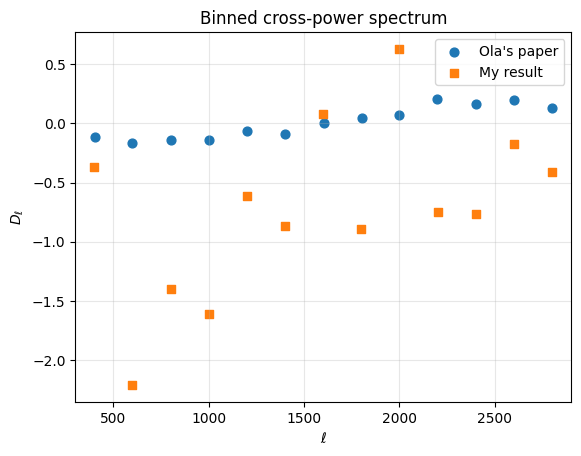

In [83]:
data = np.array([
    [402.6548672566371, -0.11770491803278688],
    [597.3451327433625, -0.1639344262295082],
    [800.8849557522124, -0.14131147540983607],
    [999.9999999999998, -0.1442622950819672],
    [1199.1150442477872, -0.06754098360655736],
    [1398.2300884955753, -0.0911475409836065],
    [1601.7699115044247, 0.005245901639344297],
    [1800.8849557522121, 0.04950819672131154],
    [2000, 0.07016393442622959],
    [2199.1150442477874, 0.20688524590163943],
    [2402.6548672566373, 0.16557377049180336],
    [2601.7699115044247, 0.1940983606557378],
    [2800.8849557522126, 0.13409836065573777]
])

plt.scatter(
    data[:, 0],
    data[:, 1],
    marker="o",
    s=40,
    label="Ola's paper"
)

plt.scatter(
    ell,
    1e12 * Dl,
    marker="s",
    s=40,
    label="My result"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [84]:
# w_dir = nmt.NmtWorkspace()
# w_dir.compute_coupling_matrix(temp_field, gal_field, b)

# cw_dir = nmt.NmtCovarianceWorkspace()
# cw_dir.compute_coupling_coefficients(temp_field, gal_field, temp_field, gal_field)

# ell_arr = b.get_effective_ells()
# ells_full = np.arange(3 * nside_gal)

# cl_full_dir = np.interp(ells_full, ell_arr, cl, left=cl[0], right=cl[-1])

# cl_full_dir = cl_full_dir.reshape(1, -1)

# cov_dir = nmt.gaussian_covariance(cw_dir, 0, 0, 0, 0, cl_full_dir, cl_full_dir, cl_full_dir, cl_full_dir, w_dir)

# nbins = len(ell_arr)

# cov = cov_dir.reshape([nbins, 1, nbins, 1])[:, 0, :, 0]
# errors = np.sqrt(np.diag(cov))

# ax.errorbar(ell_arr, cl * 1e5, yerr=1e5 * errors, fmt='o', color=colors[label], markersize=3, capsize=3, elinewidth=1)

# ax.set_xlim(100, 1000)
# ax.set_yscale("log")

# ax.set_xlabel(r'$\ell$', fontsize=16)
# ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

# ax.grid(True, alpha=0.25, linestyle='--')
# ax.legend(loc='upper right', fontsize=10)

# plt.tight_layout()
# plt.show()

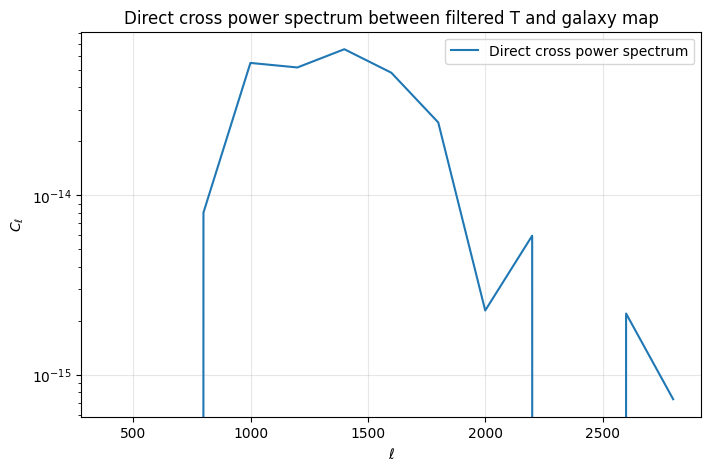

In [85]:
ell = b.get_effective_ells()
plt.figure(figsize=(8,5))
plt.plot(ell, cl_dir_cross[0], label="Direct cross power spectrum")
plt.xlabel(r"$\ell$")
plt.yscale("log")
plt.ylabel(r"$C_\ell$")
plt.title("Direct cross power spectrum between filtered T and galaxy map")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

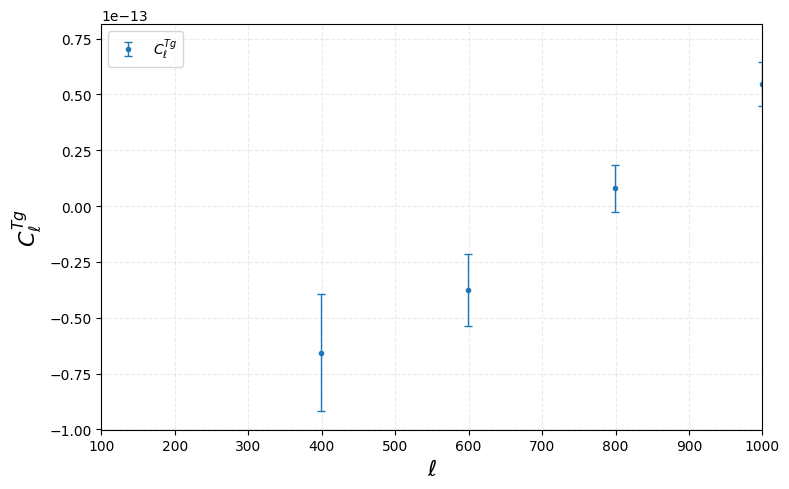

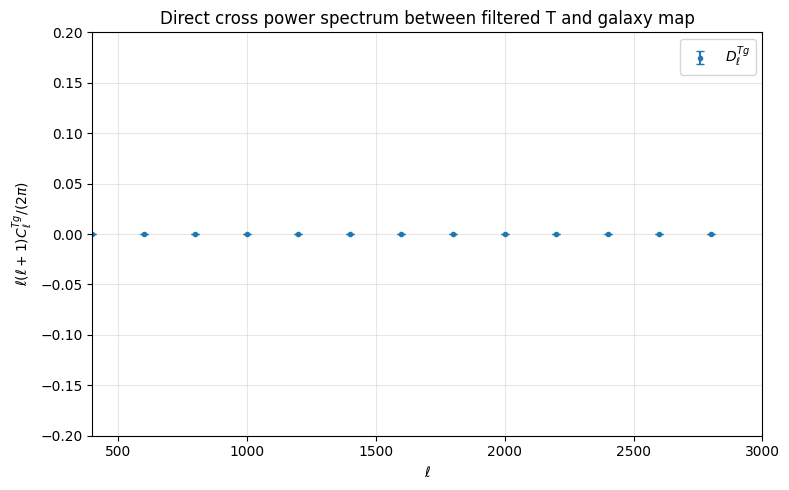

In [86]:
temp_field = nmt.NmtField(mask, [temp_filtered], lmax=l_max)
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

# Cross-spectrum: T x g
cl_tg = nmt.compute_full_master(temp_field, gal_field, b)[0]

# You also need auto-spectra for the covariance of C_l^{Tg}
cl_tt = nmt.compute_full_master(temp_field, temp_field, b)[0]
cl_gg = nmt.compute_full_master(gal_field, gal_field, b)[0]

ell_binned = b.get_effective_ells()
lmax = 3 * nside_gal - 1
ells_full = np.arange(lmax + 1)

def interp_to_full(cl_binned):
    return np.interp(
        ells_full,
        ell_binned,
        cl_binned,
        left=cl_binned[0],
        right=cl_binned[-1]
    ).reshape(1, -1)

cl_tt_full = interp_to_full(cl_tt)
cl_tg_full = interp_to_full(cl_tg)
cl_gg_full = interp_to_full(cl_gg)

# Workspace for the measured spectrum T x g
w_tg = nmt.NmtWorkspace()
w_tg.compute_coupling_matrix(temp_field, gal_field, b)

# Covariance workspace for Cov(Tg, Tg)
cw = nmt.NmtCovarianceWorkspace()
cw.compute_coupling_coefficients(
    temp_field, gal_field,
    temp_field, gal_field
)

cov_tg = nmt.gaussian_covariance(
    cw,
    0, 0, 0, 0,
    cl_tt_full, cl_tg_full,
    cl_tg_full, cl_gg_full,
    w_tg,
    wb=w_tg
)

nbins = len(ell_binned)
cov_tg = cov_tg.reshape(nbins, 1, nbins, 1)[:, 0, :, 0]
err_tg = np.sqrt(np.diag(cov_tg))

# Plot C_l
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    ell_binned,
    cl_tg,
    yerr=err_tg,
    fmt="o",
    markersize=3,
    capsize=3,
    elinewidth=1,
    label=r"$C_\ell^{Tg}$"
)

ax.set_xlim(100, 1000)
ax.set_xlabel(r"$\ell$", fontsize=16)
ax.set_ylabel(r"$C_\ell^{Tg}$", fontsize=16)
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Plot D_l = ell(ell+1) C_l / 2pi
factor = ell_binned * (ell_binned + 1) / (2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    ell_binned,
    factor * cl_tg,
    yerr=factor * err_tg,
    fmt="o",
    markersize=3,
    capsize=3,
    label=r"$D_\ell^{Tg}$"
)

ax.set_xlim(400, 3000)
ax.set_ylim(-0.2, 0.2)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{Tg}/(2\pi)$")
ax.set_title("Direct cross power spectrum between filtered T and galaxy map")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### kSZ estimation with unWISE blue

In [87]:
ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)
temp_squared_field = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)

# cl_gal = nmt.compute_full_master(gal_field, gal_field, b)
# alm_gal = hp.map2alm(gal, lmax=3000)

In [88]:
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(temp_squared_field, gal_field, b)

cl_kSZ = compute_master(temp_squared_field, gal_field, wsp)

ell = b.get_effective_ells()


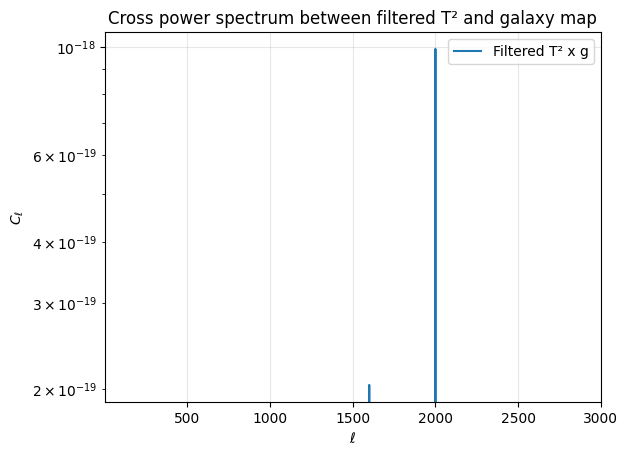

In [89]:
plt.plot(
    ell,
    cl_kSZ[0],
    label="Filtered T² x g"
)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale('log')
plt.xlim(2, 3000)
plt.title("Cross power spectrum between filtered T² and galaxy map")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [90]:
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(temp_squared_field, gal_field, b)

cw = nmt.NmtCovarianceWorkspace()
cw.compute_coupling_coefficients(temp_squared_field, gal_field, temp_squared_field, gal_field)

ell_arr = b.get_effective_ells()
ells_full = np.arange(3 * nside_gal)

cl_full = np.interp(ells_full, ell_arr, cl, left=cl[0], right=cl[-1])

cl_full = cl_full.reshape(1, -1)

cov = nmt.gaussian_covariance(cw, 0, 0, 0, 0, cl_full, cl_full, cl_full, cl_full, w)

nbins = len(ell_arr)

cov = cov.reshape([nbins, 1, nbins, 1])[:, 0, :, 0]
errors = np.sqrt(np.diag(cov))

ax.errorbar(ell_arr, cl * 1e5, yerr=1e5 * errors, fmt='o', color=colors[label], markersize=3, capsize=3, elinewidth=1)

ax.set_xlim(100, 1000)
ax.set_yscale("log")

ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

ValueError: fp and xp are not of the same length.

In [ ]:
coupling_matrix = w.get_coupling_matrix()
coupling_matrix

NameError: name 'w' is not defined

In [ ]:
# print("ell:", np.shape(ell))
# print("cl_cross:", np.shape(cl_cross))

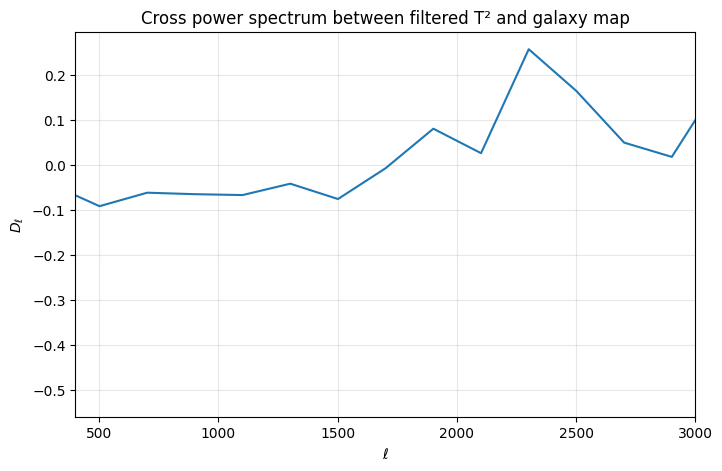

In [ ]:
cl_cross_1d = cl_cross[0]

plt.figure(figsize=(8,5))

plt.plot(ell, ell * (ell+1) * cl_cross_1d/(2*np.pi), label="Cross power spectrum")

plt.xlim(400, 3000)
#plt.ylim(-0.2, 0.2)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.title("Cross power spectrum between filtered T² and galaxy map")
plt.grid(alpha=0.3)
plt.show()



In [ ]:
# plt.figure(figsize=(8,5))

# plt.scatter(
#     ell[2:], cl_cross[2:],
#     s=10,
#     alpha=0.6,
#     # label="data points"
# )

# # plt.plot(ell, cl_cross[0], label="Cross power spectrum")
# plt.xlim(400, 3000)
# plt.ylim(-0.2, 0.2)
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$C_\ell$")
# plt.title("Cross power spectrum between filtered T² and galaxy map")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()

In [ ]:
# lmax_common = min(
#     hp.Alm.getlmax(len(alm_squared)),
#     hp.Alm.getlmax(len(alm_gal))
# )

# alm_squared_common = hp.resize_alm(
#     alm_squared,
#     lmax=hp.Alm.getlmax(len(alm_squared)),
#     mmax=hp.Alm.getlmax(len(alm_squared)),
#     lmax_out=lmax_common,
#     mmax_out=lmax_common
# )

# alm_gal_common = hp.resize_alm(
#     alm_gal,
#     lmax=hp.Alm.getlmax(len(alm_gal)),
#     mmax=hp.Alm.getlmax(len(alm_gal)),
#     lmax_out=lmax_common,
#     mmax_out=lmax_common
# )

# cl_kSZ = hp.alm2cl(alm_squared_common, alm_gal_common)

# ell = np.arange(len(cl_kSZ))

# Dl = ell * (ell + 1) * cl_kSZ / (2 * np.pi)

# plt.figure(figsize=(8, 5))

# # # --- line (gives continuity)
# # plt.plot(
# #     ell[2:], Dl[2:],
# #     linewidth=1.5,
# #     alpha=0.8,
# #     label="spectrum (line)"
# # )

# # --- scatter (shows discrete multipoles)
# plt.scatter(
#     ell[2:], Dl[2:],
#     s=10,          # smaller than before so it doesn't clutter
#     alpha=0.6,
#     label="data points"
# )

# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$D_\ell$")
# plt.title(r"Cross power spectrum between filtered $T^2$ and galaxy map")
# plt.grid(alpha=0.3)
# plt.legend()

# plt.show()


In [ ]:
# alm_kSZ = alm_squared * alm_gal
# cl_kSZ = hp.alm2cl(alm_kSZ)
# ell = np.arange(len(cl_kSZ))

# plt.figure(figsize=(8, 5))
# plt.plot(
#     ell[2:],
#     ell[2:] * (ell[2:] + 1) * cl_kSZ[2:] / (2 * np.pi),
#     label="kSZ-gal cross power spectrum"
# )
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$D_\ell$")
# plt.title("Cross power spectrum between filtered T² and galaxy map")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()

### extend to full sample

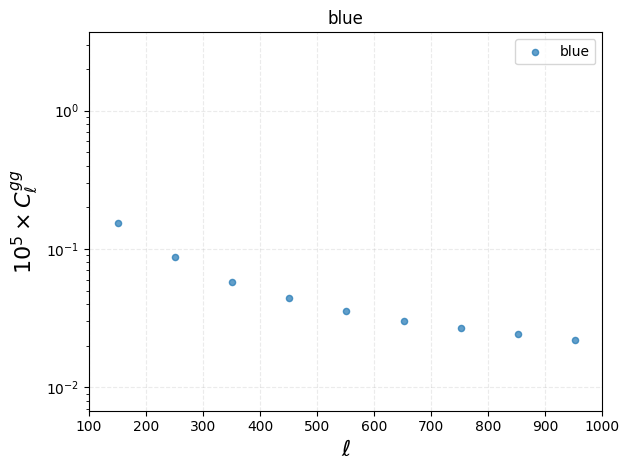

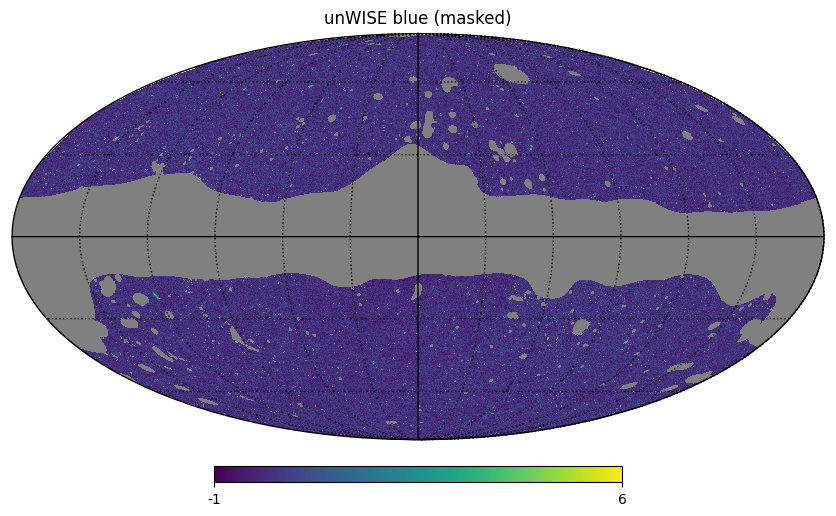

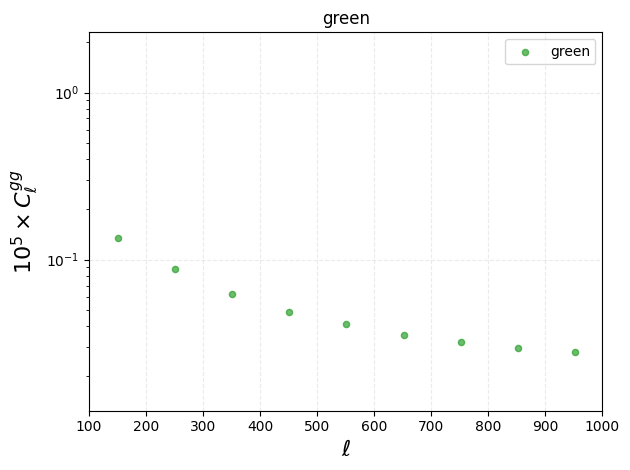

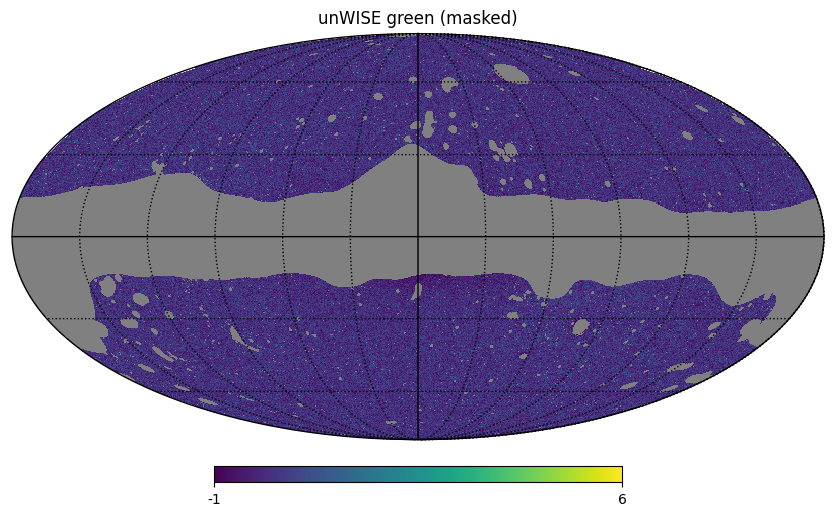

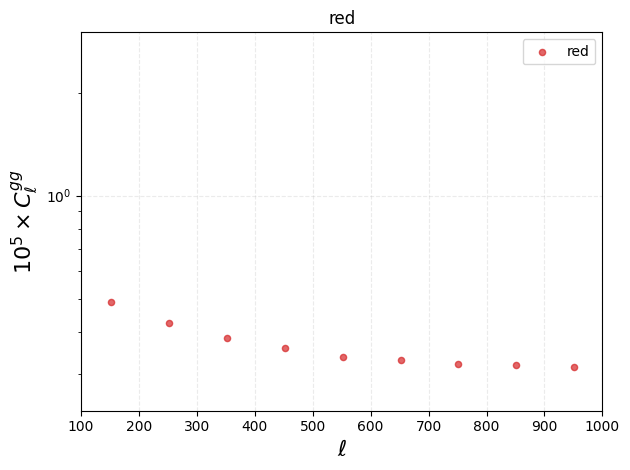

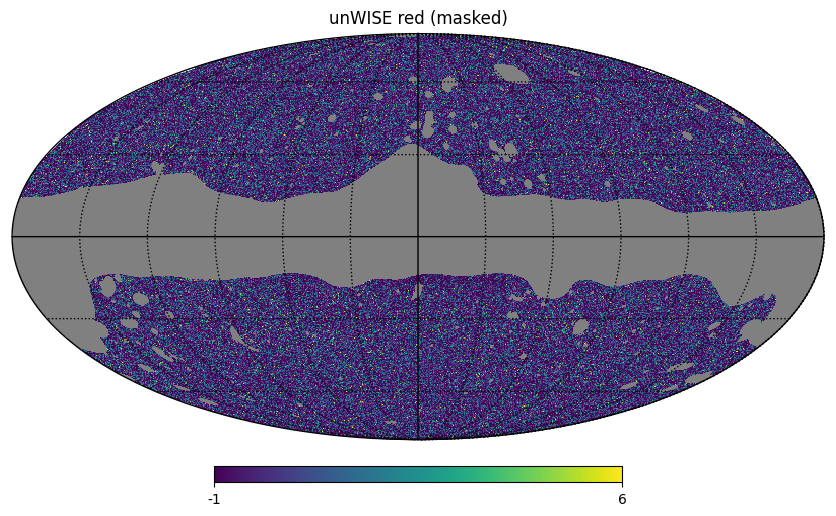

In [ ]:
samples = {
    "blue": hp.read_map("../galaxy_samples/1_delta.fits", field=0),
    "green": hp.read_map("../galaxy_samples/2_delta.fits", field=0),
    "red": hp.read_map("../galaxy_samples/7_delta.fits", field=0),
}

colors = {
    "blue": "tab:blue",
    "green": "tab:green",
    "red": "tab:red"
}

nside_gal = hp.get_nside(samples["blue"])

b = nmt.NmtBin.from_nside_linear(nside_gal, 100)
ell_arr = b.get_effective_ells()

for label, gal_map in samples.items():
    fig, ax = plt.subplots()
    field = nmt.NmtField(mask, [gal_map])
    cl = nmt.compute_full_master(field, field, b)[0]

    ax.scatter(
        ell_arr,
        1e5 * cl,
        label=label,
        s=20,
        color=colors[label],
        alpha=0.7
    )

    ax.set_title(label)
    ax.legend()
    ax.set_xlim(100, 1000)
    ax.set_yscale("log")

    ax.set_xlabel(r'$\ell$', fontsize=16)
    ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

    alm_gal = hp.map2alm(gal_map, lmax=3000)
    gal_map = hp.alm2map(alm_gal, lmax=3000, nside=nside_gal)
    
    gal_masked = gal_map * mask
    gal_masked = np.where(mask > 0, gal_map, hp.UNSEEN)
    hp.mollview(gal_masked, title = f"unWISE {label} (masked)", cmap = cmap, min=-1, max=6)
    hp.graticule()

    # hp.mollview(gal_masked, coord=['G','C'])
    plt.show()

In [ ]:
l_min = 300
l_max = 2900
delta_l = 200

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1
b = nmt.NmtBin.from_edges(ells_low, ells_high)

In [ ]:
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)
temp_squared_field = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)

# cl_gal = nmt.compute_full_master(gal_field, gal_field, b)
# alm_gal = hp.map2alm(gal, lmax=3000)

In [ ]:
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(temp_squared_field, gal_field, b)

cl_kSZ = compute_master(temp_squared_field, gal_field, wsp)

ell = b.get_effective_ells()